In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from pylr2 import regress2

warnings.filterwarnings('ignore', message="Could not infer format")

In [167]:
filepath = os.path.join('Data', 'precip_CORMP_04132026.csv')
df_full = pd.read_csv(filepath, header = None, parse_dates = [1], skiprows=6)
df_full.columns = ['Datetime Transmission','Rainfall (mm)', 'NaN']
df_full.head()

,Datetime Transmission,Rainfall (mm),NaN
0,Time (utc),CMSDOCK Rain (last 15 min) (in),CMSDOCK Rain (last 15 min) (in) quality
1,2025-12-19 05:00,0.07,not evaluated
2,2025-12-19 05:15,0.04,not evaluated
3,2025-12-19 05:30,0.02,not evaluated
4,2025-12-19 05:45,0.01,not evaluated


In [168]:
filepath = os.path.join('Data', 'precip_Davis_04132026.csv')
df_full = pd.read_csv(filepath, header = None, parse_dates = [1], skiprows=7)
df_full.columns = ['Datetime Transmission','Rainfall (mm)']
df_full.head()

,Datetime Transmission,Rainfall (mm)
0,12/19/25 12:15 AM,1.0
1,12/19/25 12:30 AM,0.5
2,12/19/25 12:45 AM,0.3
3,12/19/25 1:00 AM,0.0
4,12/19/25 1:15 AM,0.0


In [169]:
filepath = os.path.join('Data', 'OWLR_CMS_04152026.csv')
df_full = pd.read_csv(filepath, header = None, parse_dates = [1])
df_full.columns = ['Device_ID', 'Datetime Transmission', 'Blank', 'Event', 'Unix Time', 'Distance (cm)', 'Rainfall (mm)', 'Battery (V)', 'Charge (%)']
df_full.head()

,Device_ID,Datetime Transmission,Blank,Event,Unix Time,Distance (cm),Rainfall (mm),Battery (V),Charge (%)
0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,e00fce681282837e5d0586e0,2025-11-25 09:25:36,NaN,rainfall,1.764081e+09,60.36389,0.0,0.17,0.00
2,e00fce681282837e5d0586e0,2025-11-25 09:36:14,NaN,rainfall,9.466848e+08,27.66250,0.0,0.17,91.96
3,e00fce681282837e5d0586e0,2025-11-25 09:41:31,NaN,rainfall,9.466848e+08,39.67778,0.0,0.17,92.60
4,e00fce681282837e5d0586e0,2025-11-25 10:00:52,NaN,rainfall,1.764083e+09,164.17084,1.4,0.05,83.03


Configuration:

Defining configuration parameters and file paths for the rainfall analysis project. This includes the file paths for the CORMP, Davis, and OWLR datasets, as well as the start and end timestamps for the analysis period.


In [170]:
FILES = {
    "cormp": "Data/precip_CORMP_04132026.csv",
    "davis": "Data/precip_Davis_04132026.csv",
    "owlr":  "Data/OWLR_CMS_04132026.csv"
}

START = pd.to_datetime("2025-12-19 09:00")
END   = pd.to_datetime("2026-04-13 08:00")

Analysis wide variables:

Creating reusable functions to clean, align, and process rainfall data across sensors.

In [171]:
def keep_period(df):
    return df[(df["datetime"].between(START, END))].reset_index(drop=True)

def finalize(df, col_name, resample=True):
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")
    df = df[["datetime", col_name]].dropna()

    if resample:
        df = df.set_index("datetime").resample("h", closed="right", label="right").sum().reset_index()
#when summing for pandas bins  are left-closed, right-open: [11:00, 12:00) and labeled by the left edge sp this code changes it to the other way.

    return keep_period(df)

Sensor-specific changes:

Cleaning and combining rainfall data from different sensors so they all match the same format.

In [172]:
def load_cormp(fp):
    df = pd.read_csv(fp, skiprows=6, usecols=[0, 1])
    df.columns = ["datetime", "rain"]
    df["rain"] *= 25.4
    return finalize(df, "rain")


def load_davis(fp):
    df = pd.read_csv(fp, skiprows=7, names=["datetime", "rain"])
    return finalize(df, "rain")


def load_owlr(fp):
    df = pd.read_csv(fp, header=None,
                     names=["device_id", "datetime", "blank", "event", "payload"])
    df["rain"] = df["payload"].str.split(",").str[2]
    return finalize(df, "rain", resample=False)

def prepare(df, name):
    df["datetime"] = df["datetime"].dt.floor("h")
    return df.rename(columns={"rain": name})


Loads raw rainfall data from each sensor, standardizes it, and merges everything into one combined dataset for comparison in future analyses. 

In [173]:
# --- Run ---
print("Loading and processing rainfall data...")

cormp = prepare(load_cormp(FILES["cormp"]), "tr525_mm")
davis = prepare(load_davis(FILES["davis"]), "aerocone_mm")
owlr  = prepare(load_owlr(FILES["owlr"]),  "owlr_mm")

rainfall_all = (
    cormp.merge(davis, on="datetime", how="outer")
          .merge(owlr, on="datetime", how="outer")
)

print(f"  TR-525l: {len(cormp)} hourly records")
print(f"  Davis: {len(davis)} hourly records")
print(f"  OWLR: {len(owlr)} hourly records")
print(f"  Combined comparison table: {rainfall_all.shape}")

Loading and processing rainfall data...
  TR-525l: 2760 hourly records
  Davis: 2760 hourly records
  OWLR: 2753 hourly records
  Combined comparison table: (2765, 4)


Global names and colors

In [174]:
SENSORS = {
    "cormp": {
        "col": "rain_mm_cormp",
        "label": "TR525l",
        "color": "crimson",
        "marker": "s",
        "is_ref": True
    },
    "davis": {
        "col": "rain_mm_davis",
        "label": "Aerocone",
        "color": "steelblue",
        "marker": "o",
        "is_ref": False
    },
    "owlr": {
        "col": "rain_mm_owlr",
        "label": "OWLR",
        "color": "darkgreen",
        "marker": "^",
        "is_ref": False
    }
}

Setting start and end dates

In [175]:
def filter_window(df, start, end):
    return df[df["datetime"].between(pd.to_datetime(start), pd.to_datetime(end))].reset_index(drop=True)

Finished data sets: 
Extracts a specific time dataset from all sensors, standardizes column names, and ends up optionally applying OWLR calibration which I will use in event specific analyses. 

In [176]:
def build_event_frame(start, end, calibrate_owlr=False, m=None, b=None):
    df = filter_window(rainfall_all, start, end).copy()

    df = df.rename(columns={
        "tr525_mm":    "rain_mm_cormp",
        "aerocone_mm": "rain_mm_davis",
        "owlr_mm":     "rain_mm_owlr"
    })

    if calibrate_owlr:
        if m is None or b is None:
            raise ValueError("Provide calibration coefficients m and b.")
        df["rain_mm_owlr_cal"] = (m * df["rain_mm_owlr"] + b).clip(lower=0)

    return df



Global r-squared: Compares two sensors by matching their data points and calculating how strongly they agree

In [177]:
def paired_metrics(df, x, y):
    pair = df[[x, y]].dropna()
    if len(pair) < 2:
        return pair, np.nan, np.nan
    r = pair[x].corr(pair[y])
    return pair, r, r**2

# Linear Regression of TR525 vs. OWLR and Aerocone

In [178]:

# Build full-period comparison frame using consistent names
full_df = build_event_frame(START, END)
XCOL = 'rain_mm_cormp'

def stats_pair(x, y):
    pair = pd.concat([x, y], axis=1).dropna()
    if len(pair) < 2:
        return pair, np.nan, np.nan, np.nan, np.nan

    x_clean = pair.iloc[:, 0]
    y_clean = pair.iloc[:, 1]
    r = x_clean.corr(y_clean)
    r2 = r ** 2 if pd.notna(r) else np.nan
    slope, intercept = np.polyfit(x_clean, y_clean, 1)
    return pair, r, r2, slope, intercept

print("=" * 70)
print("FULL PERIOD ANALYSIS: TR525 vs Sensors")
print("=" * 70)
print(f"\nTR525 records: {full_df[XCOL].notna().sum()}")

results = {}

# Compare each non-reference sensor against TR-525l
for sensor_name, cfg in SENSORS.items():
    if cfg.get('is_ref', False):
        continue

    col = cfg['col']
    results[sensor_name] = stats_pair(full_df[XCOL], full_df[col])
    pair, r, r2, slope, intercept = results[sensor_name]

    print()
    print("TR525 vs", sensor_name)
    print("  Paired points:", len(pair))
    print("  R²:", round(r2, 4) if pd.notna(r2) else np.nan)
    print("  Slope:", round(slope, 4) if pd.notna(slope) else np.nan)
    print("  Intercept:", round(intercept, 4) if pd.notna(intercept) else np.nan)


FULL PERIOD ANALYSIS: TR525 vs Sensors

TR525 records: 2765

TR525 vs davis
  Paired points: 2765
  R²: 0.0191
  Slope: 0.1572
  Intercept: 0.0565

TR525 vs owlr
  Paired points: 2753
  R²: 0.0141
  Slope: 0.0873
  Intercept: 0.0269


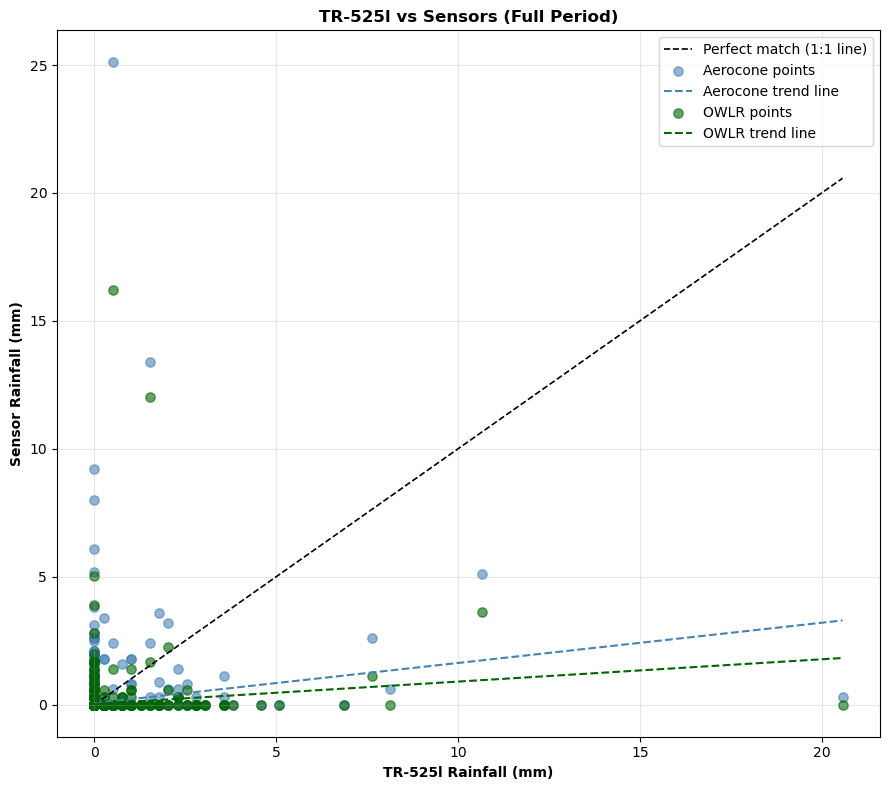

In [179]:
plt.figure(figsize=(9, 8))

# Get TR-525l data (reference sensor)
tr525 = full_df[XCOL].dropna()
x_min = tr525.min()
x_max = tr525.max()

# Draw the "perfect match" line
plt.plot(
    [x_min, x_max],
    [x_min, x_max],
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='Perfect match (1:1 line)'
)

# Loop through each non-reference sensor
for sensor_name, cfg in SENSORS.items():
    if cfg.get('is_ref', False):
        continue

    column = cfg['col']
    color = cfg['color']
    label = cfg['label']

    # Remove missing values for paired plotting
    clean_data = full_df[[XCOL, column]].dropna()
    x_values = clean_data[XCOL]
    y_values = clean_data[column]

    # Plot observed points
    plt.scatter(
        x_values,
        y_values,
        s=45,
        alpha=0.6,
        color=color,
        label=f'{label} points'
    )

    # Plot trend line from the computed regression
    _, _, _, slope, intercept = results[sensor_name]
    if pd.notna(slope) and pd.notna(intercept):
        x_line = np.linspace(x_min, x_max, 100)
        y_line = slope * x_line + intercept
        plt.plot(
            x_line,
            y_line,
            '--',
            color=color,
            label=f'{label} trend line'
        )

plt.xlabel('TR-525l Rainfall (mm)', fontweight='bold')
plt.ylabel('Sensor Rainfall (mm)', fontweight='bold')
plt.title('TR-525l vs Sensors (Full Period)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Type 2 Regression Steps

In [180]:
# # Use the sensor-specific hourly tables created in the loading cell
# paired = rainfall_all[['datetime', 'tr525_mm', 'owlr_mm']].dropna()
# paired_aero = rainfall_all[['datetime', 'tr525_mm', 'aerocone_mm']].dropna()

# # Validate sufficient data for regression
# if len(paired) < 2 or len(paired_aero) < 2:
#     raise ValueError('Not enough overlapping hourly points for Type II regression.')

# Extract variables for regression
x = paired['tr525_mm'].to_numpy()
y = paired['owlr_mm'].to_numpy()
x_aero = paired_aero['tr525_mm'].to_numpy()
y_aero = paired_aero['aerocone_mm'].to_numpy()

In [181]:

fit = regress2(x, y, _method_type_2='reduced major axis')
slope = fit.get('slope', np.nan)
intercept = fit.get('intercept', np.nan)
r = fit.get('r', np.corrcoef(x, y)[0, 1])
r2 = r**2 if np.isfinite(r) else np.nan

fit_aero = regress2(x_aero, y_aero, _method_type_2='reduced major axis')
slope_aero = fit_aero.get('slope', np.nan)
intercept_aero = fit_aero.get('intercept', np.nan)
r_aero = fit_aero.get('r', np.corrcoef(x_aero, y_aero)[0, 1])
r2_aero = r_aero**2 if np.isfinite(r_aero) else np.nan

# Calculate residuals and performance metrics
y_hat = slope * x + intercept
residuals = y - y_hat
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))
resid_mean = np.mean(residuals)
resid_std = np.std(residuals, ddof=1)

# Print regression results
print(f'Overlapping hourly points: OWLR={len(paired)}, Aerocone={len(paired_aero)}')
print(f'\nType II RMA regression equations:')
print(f'  OWLR = {slope:.4f} × TR-525l + {intercept:.4f}')
print(f'  Aerocone = {slope_aero:.4f} × TR-525l + {intercept_aero:.4f}')
print(f'\nRegression fit statistics:')
print(f'  OWLR: r = {r:.4f}, r² = {r2:.4f}')
print(f'  Aerocone: r = {r_aero:.4f}, r² = {r2_aero:.4f}')
print(f'\nOWLR residual statistics (mm):')
print(f'  Mean: {resid_mean:.4f} | Std Dev: {resid_std:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}')



Overlapping hourly points: OWLR=2753, Aerocone=2765

Type II RMA regression equations:
  OWLR = 0.7114 × TR-525l + -0.0123
  Aerocone = 1.1637 × TR-525l + -0.0065

Regression fit statistics:
  OWLR: r = 0.1922, r² = 0.0369
  Aerocone: r = 0.0950, r² = 0.0090

OWLR residual statistics (mm):
  Mean: -0.0000 | Std Dev: 0.5503 | MAE: 0.0755 | RMSE: 0.5502


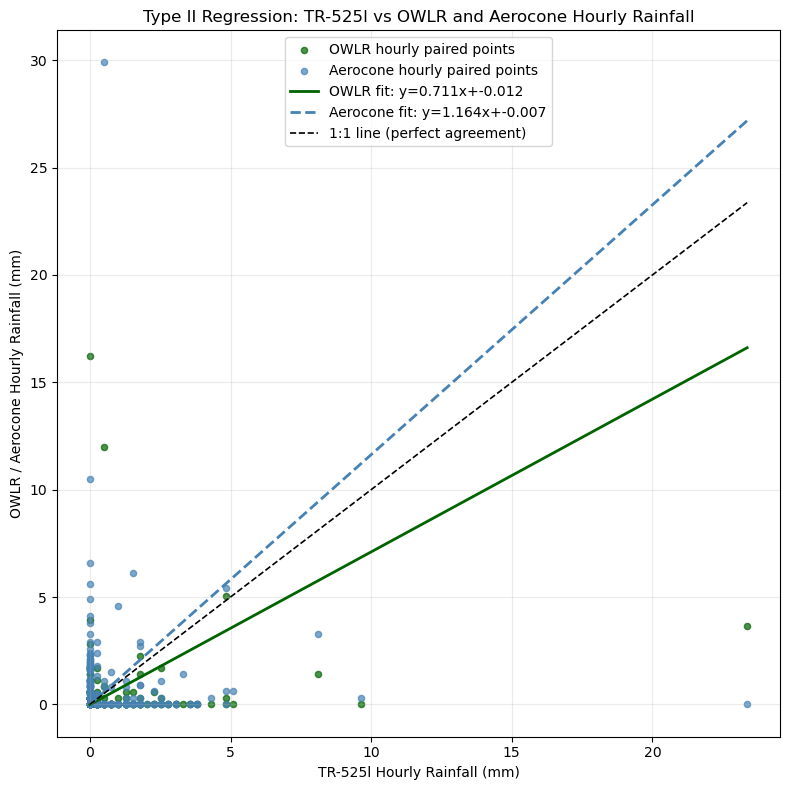

In [182]:
plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=20, alpha=0.7, label='OWLR hourly paired points', color='darkgreen')
plt.scatter(x_aero, y_aero, s=20, alpha=0.7, label='Aerocone hourly paired points', color='steelblue')

xmin = min(np.nanmin(x), np.nanmin(x_aero))
xmax = max(np.nanmax(x), np.nanmax(x_aero))
xline = np.linspace(xmin, xmax, 200)
plt.plot(xline, slope * xline + intercept, color='darkgreen', lw=2,
         label=f'OWLR fit: y={slope:.3f}x+{intercept:.3f}')
plt.plot(xline, slope_aero * xline + intercept_aero, color='steelblue', lw=2, ls='--',
         label=f'Aerocone fit: y={slope_aero:.3f}x+{intercept_aero:.3f}')
plt.plot(xline, xline, color='black', ls='--', lw=1.2, label='1:1 line (perfect agreement)')

plt.xlabel('TR-525l Hourly Rainfall (mm)')
plt.ylabel('OWLR / Aerocone Hourly Rainfall (mm)')
plt.title('Type II Regression: TR-525l vs OWLR and Aerocone Hourly Rainfall')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


-3.8714642340724676e-18


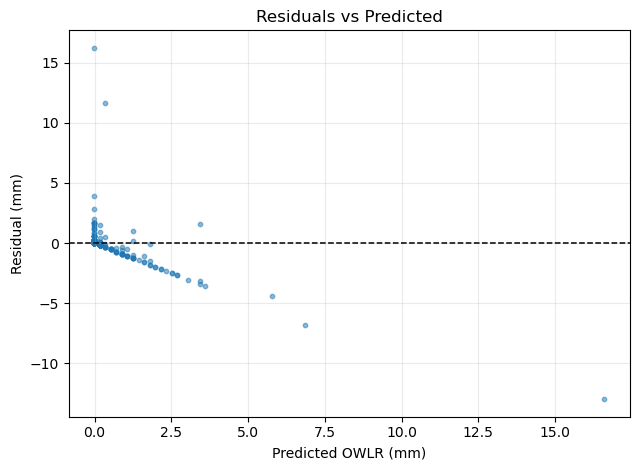

In [183]:
# Plot 2 of Residuals vs predicted values (for OWLR comparison)
plt.figure(figsize=(6.5, 4.8))
plt.scatter(y_hat, residuals, s=10, alpha=0.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1.1)
plt.xlabel('Predicted OWLR (mm)')
plt.ylabel('Residual (mm)')
plt.title('Residuals vs Predicted')
print(np.mean(residuals))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

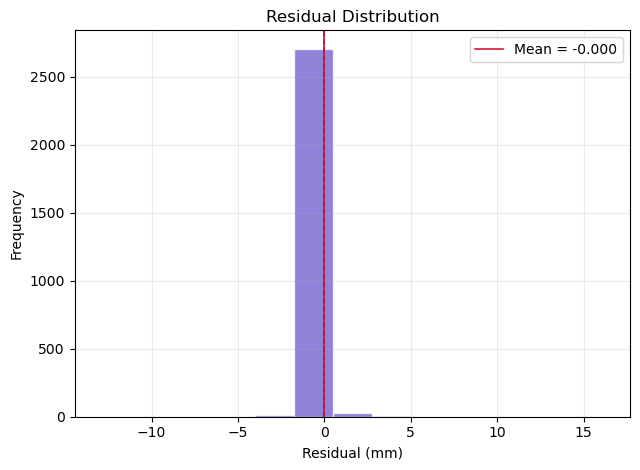

In [184]:
# Plot 3 of Residual distribution (for OWLR comparison)
plt.figure(figsize=(6.5, 4.8))
plt.hist(residuals, bins='auto', color='slateblue', alpha=0.75, edgecolor='white')
plt.axvline(0, color='black', linestyle='--', linewidth=1.1)
plt.axvline(resid_mean, color='crimson', linestyle='-', linewidth=1.2, label=f'Mean = {resid_mean:.3f}')
plt.xlabel('Residual (mm)')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Post-Calibration for OWLR

Just preparing to compare all sensors to a reference sensor and plot everything

In [185]:
# --- Build base ---
df = build_event_frame(start_cmp, end_cmp).rename(
    columns={'rain_mm_cormp': 'tr525'}
)

# --- Helper: build paired dataset ---
def get_pair(df, col):
    return df[['tr525', col]].dropna()

owlr_df = get_pair(df, 'rain_mm_owlr')
aero_df = get_pair(df, 'rain_mm_davis')



A calibration and performance eval of the OWLR sensor against TR-525l, with a comparison to Aerocone.

In [186]:
if len(owlr_df) < 2:
    print("Not enough OWLR points for calibration regression.")

else:
    # --- Calibration using reference sensor (CORMP / TR-525) ---
    owlr_raw = owlr_df['rain_mm_owlr']
    tr525 = owlr_df['tr525']   # reference sensor

    m, b, r, *_ = stats.linregress(owlr_raw, tr525)

    # Apply calibration ONLY to OWLR
    owlr_df['owlr_cal'] = m * owlr_raw + b

    # --- Metrics helper ---
    def metrics(obs, ref):
        r = ref.corr(obs)
        r2 = r**2 if pd.notna(r) else np.nan
        rmse = np.sqrt(np.mean((obs - ref) ** 2))
        return r2, rmse

    r2_raw, rmse_raw = metrics(owlr_raw, tr525)
    r2_cal, rmse_cal = metrics(owlr_df['owlr_cal'], tr525)

    print(f"Calibration: OWLR_cal = {m:.4f} * OWLR_raw + {b:.4f}")
    print(f"R² raw: {r2_raw:.4f} | RMSE raw: {rmse_raw:.4f}")
    print(f"R² cal: {r2_cal:.4f} | RMSE cal: {rmse_cal:.4f}")

    # --- Aerocone metrics ---
    if len(aero_df) >= 2:
        r2_aero, rmse_aero = metrics(
            aero_df['rain_mm_davis'],
            aero_df['tr525']
        )
        print(f"R² Aerocone: {r2_aero:.4f} | RMSE: {rmse_aero:.4f}")

Calibration: OWLR_cal = 0.1619 * OWLR_raw + 0.0573
R² raw: 0.0141 | RMSE raw: 0.6894
R² cal: 0.0141 | RMSE cal: 0.5854
R² Aerocone: 0.0191 | RMSE: 0.8278


Plot TR525 vs. calibrated OWLR and Aerocone

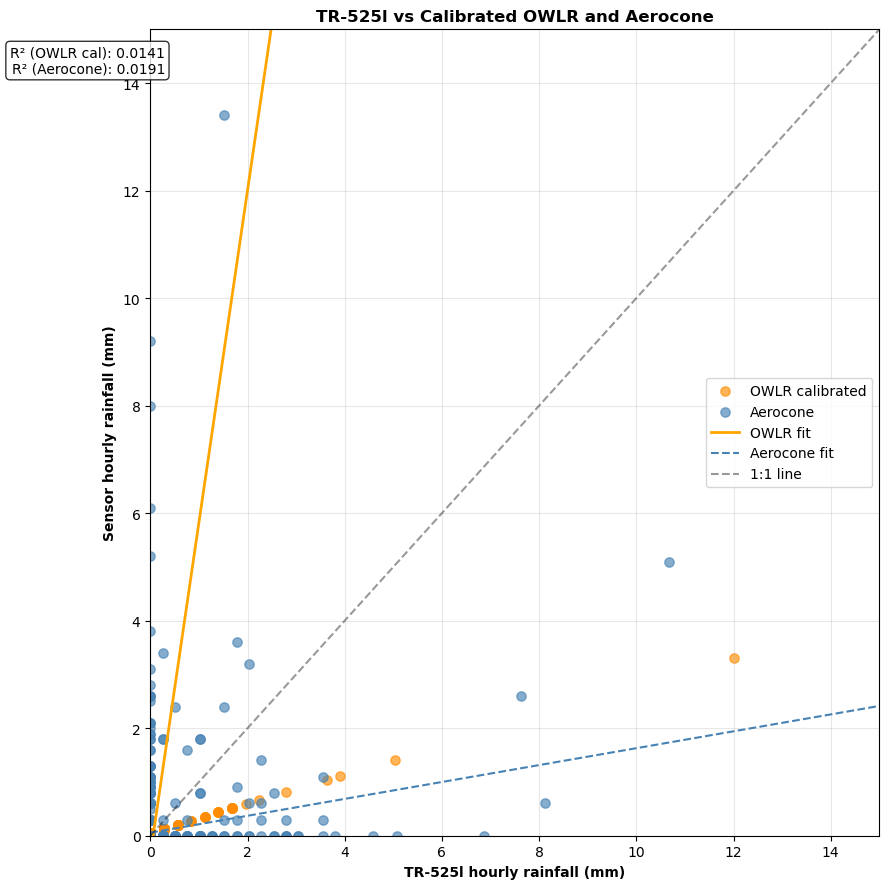

In [187]:

    plt.figure(figsize=(9, 9))

    # OWLR calibrated
    plt.scatter(y, owlr_cal, s=45, alpha=0.65, color='darkorange', label='OWLR calibrated')

    # Aerocone
    if not aero_df.empty:
        plt.scatter(aero_df['tr525'], aero_df['rain_mm_davis'],
                    s=45, alpha=0.65, color='steelblue', label='Aerocone')

    # --- Lines ---
    x_line = np.linspace(y.min(), y.max(), 200)

    # OWLR raw fit (inverted form)
    if not np.isclose(m, 0):
        plt.plot(x_line, (x_line - b) / m, color='orange', lw=2, label='OWLR fit')

    # Aerocone fit
    if len(aero_df) >= 2:
        m_a, b_a, *_ = stats.linregress(aero_df['tr525'], aero_df['rain_mm_davis'])
        plt.plot(x_line, m_a * x_line + b_a, '--', color='steelblue', label='Aerocone fit')

    # Set the maximum value we want to show on the plot
    max_value = 15

    # Create a 1:1 line (where x equals y)
    # This is a reference line to compare predictions vs actual values
    plt.plot([0, max_value], [0, max_value], 
         color='black', linestyle='--', alpha=0.4, label='1:1 line')

    # Set the limits of the x-axis and y-axis so they match
    plt.xlim(0, max_value)
    plt.ylim(0, max_value)

    # --- Labels ---
    plt.xlabel('TR-525l hourly rainfall (mm)', fontweight='bold')
    plt.ylabel('Sensor hourly rainfall (mm)', fontweight='bold')
    plt.title('TR-525l vs Calibrated OWLR and Aerocone', fontweight='bold')

    # --- Annotation ---
    text = [f'R² (OWLR cal): {r2_cal:.4f}']
    if pd.notna(r2_aero):
        text.append(f'R² (Aerocone): {r2_aero:.4f}')

    plt.gca().text(
        0.02, 0.98, '\n'.join(text),
        transform=plt.gca().transAxes,
        va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [188]:
from matplotlib.colors import LogNorm

# Build paired calibration data, can I global this?
x = compare_df['rain_mm_tr525l'].to_numpy()
y = (m * compare_df['rain_mm_owlr'] + b).to_numpy()

# invalid values??
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]

if len(x) < 2:
    raise ValueError("Not enough valid data for 2D histogram.")

# Center around mean
x_anom = x - np.mean(x)
y_anom = y - np.mean(y)

# --- Define bin size (controls resolution of rainfall structure) ---
bin_size = 0.25
lim = np.percentile(np.abs(np.concatenate([x_anom, y_anom])), 99)

edges = np.arange(-lim, lim + bin_size, bin_size)



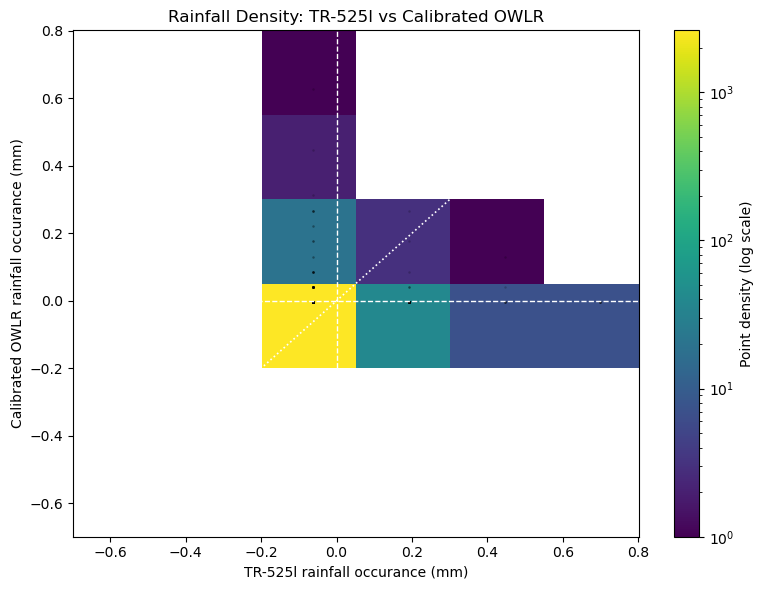

In [189]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

# 2D histogram (density view)
hist = ax.hist2d(
    x_anom,
    y_anom,
    bins=[edges, edges],
    cmap='viridis',
    norm=LogNorm(vmin=1)
)

# Colorbar
cbar = plt.colorbar(hist[3], ax=ax)
cbar.set_label("Point density (log scale)")

# Optional: overlay raw points (very light)
ax.scatter(x_anom, y_anom, s=3, alpha=0.2, color='black', linewidths=0)

# Reference lines
ax.axhline(0, color='white', linestyle='--', linewidth=1)
ax.axvline(0, color='white', linestyle='--', linewidth=1)
ax.plot([-lim, lim], [-lim, lim], 'w:', linewidth=1.2, label="1:1 line")

# Labels
ax.set_xlabel("TR-525l rainfall occurance (mm)")
ax.set_ylabel("Calibrated OWLR rainfall occurance (mm)")
ax.set_title("Rainfall Density: TR-525l vs Calibrated OWLR")

plt.tight_layout()
plt.show()

TR-525l points plotted: 2760
Aerocone points plotted: 2760
OWLR calibrated points plotted: 2753


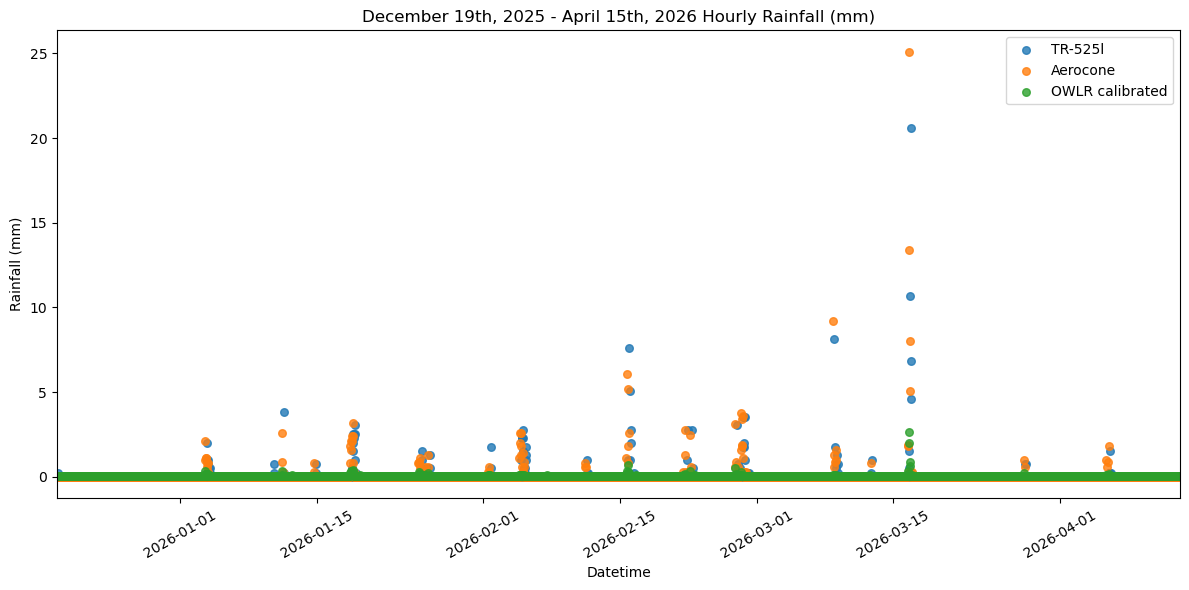

In [190]:
# Full period scatter plot with calibrated OWLR points
coeff_m = globals().get('m')
coeff_b = globals().get('b')
if coeff_m is None or coeff_b is None:
    raise ValueError('Run the calibration cell first to compute calibration coefficients m and b.')

# Apply calibration to full-period OWLR data: OWLR_cal = m * OWLR_raw + b
owlr_calibrated = owlr.copy()
owlr_calibrated['rain_mm_cal'] = (coeff_m * owlr_calibrated['owlr_mm'] + coeff_b).clip(lower=0)

# Count the actual points that will be used in each scatter layer
cormp_points = cormp[['datetime', 'tr525_mm']].dropna().shape[0]
davis_points = davis[['datetime', 'aerocone_mm']].dropna().shape[0]
owlr_points = owlr_calibrated[['datetime', 'rain_mm_cal']].dropna().shape[0]

print(f'TR-525l points plotted: {cormp_points}')
print(f'Aerocone points plotted: {davis_points}')
print(f'OWLR calibrated points plotted: {owlr_points}')

plt.figure(figsize=(12, 6))
if not cormp.empty:
    plt.scatter(cormp['datetime'], cormp['tr525_mm'], label='TR-525l', s=30, alpha=0.8)
if not davis.empty:
    plt.scatter(davis['datetime'], davis['aerocone_mm'], label='Aerocone', s=30, alpha=0.8)
if not owlr_calibrated.empty:
    plt.scatter(owlr_calibrated['datetime'], owlr_calibrated['rain_mm_cal'], label='OWLR calibrated', s=30, alpha=0.8)

plt.xlabel('Datetime')
plt.ylabel('Rainfall (mm)')
plt.title('December 19th, 2025 - April 15th, 2026 Hourly Rainfall (mm)')
plt.legend()
plt.xlim(START, END)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
